# Classificação de Cobertura do Solo — EuroSAT · CNNs do zero

**Global Solution 2026/1 · Applied Computer Vision · Grupo TPGN (TechPulse GlobalNetwork)**

Projeto integrado: plataforma de dados de precisão para agro e cidades a partir de imagens
de satélite. Esta camada de Visão Computacional classifica tiles Sentinel-2 em 10 classes de
cobertura/uso do solo, usando **redes neurais convolucionais treinadas do zero** (sem modelos
pré-treinados). ODS 2, 9 e 11.

**Integrantes:**
- GUILHERME ROCHA BIANCHINI — RM97974
- NIKOLAS RODRIGUES MOURA DOS SANTOS — RM551566
- PEDRO HENRIQUE PEDROSA TAVARES — RM97877
- RODRIGO BRASILEIRO — RM98952
- THIAGO JARDIM DE OLIVEIRA — RM551624

**Author:** GUILHERME ROCHA BIANCHINI

> Recomendado rodar no Google Colab com GPU (Ambiente de execução > Alterar tipo > GPU).

## 1. Setup e reprodutibilidade

In [1]:
# Author: GUILHERME ROCHA BIANCHINI - TPGN / Global Solution 2026
import os, random, json, io
import os, zipfile, urllib.request, glob
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# pastas de saida (caso rode fora da estrutura do repo)
os.makedirs("reports/figures", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("samples", exist_ok=True)

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset — EuroSAT (RGB, Sentinel-2, 10 classes)

In [2]:
# A fonte original do EuroSAT (madm.dfki.de) costuma cair / retornar HTTP 403.
# Baixamos o mirror estavel do torchgeo no Hugging Face (EuroSAT.zip RGB, ~94 MB).
URL = "https://huggingface.co/datasets/torchgeo/eurosat/resolve/main/EuroSAT.zip"
os.makedirs("data", exist_ok=True)
zip_path = "data/EuroSAT.zip"
if not os.path.exists(zip_path):
    print("Baixando EuroSAT..."); urllib.request.urlretrieve(URL, zip_path)
with zipfile.ZipFile(zip_path) as z:
    z.extractall("data")

# Localiza a pasta que contem as 10 subpastas de classe (o zip extrai em data/2750/).
root = None
for d, subs, _ in os.walk("data"):
    class_dirs = [s for s in subs if os.path.isdir(os.path.join(d, s))]
    if len(class_dirs) == 10:
        root = d; break
assert root, "Pasta com as 10 classes nao encontrada"
print("Pasta de classes:", root)

CLASSES = sorted(os.listdir(root))
paths, lab = [], []
for i, c in enumerate(CLASSES):
    for p in glob.glob(os.path.join(root, c, "*.jpg")):
        paths.append(p); lab.append(i)

images = np.zeros((len(paths), 64, 64, 3), dtype=np.uint8)
for k, p in enumerate(paths):
    images[k] = np.array(Image.open(p).convert("RGB").resize((64, 64)))
labels = np.array(lab, dtype=np.int64)

print(images.shape, labels.shape, "| classes:", len(CLASSES))
print(CLASSES)

Baixando EuroSAT...
Pasta de classes: data/2750
(27000, 64, 64, 3) (27000,) | classes: 10
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### 2.1 EDA — distribuição por classe

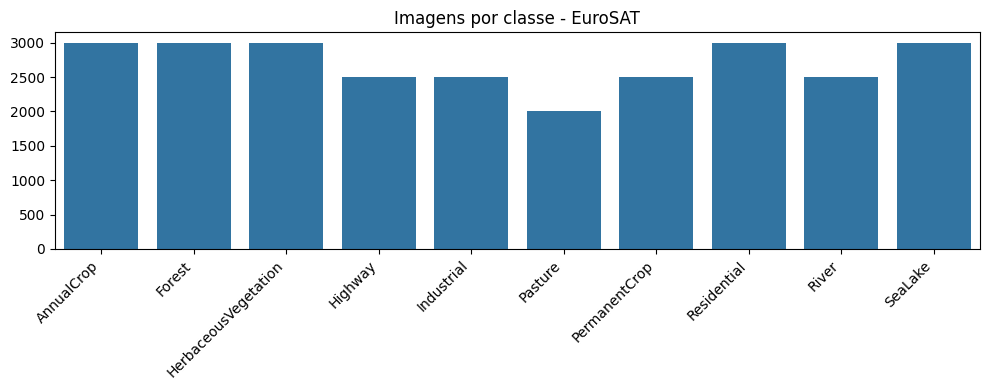

{'AnnualCrop': 3000, 'Forest': 3000, 'HerbaceousVegetation': 3000, 'Highway': 2500, 'Industrial': 2500, 'Pasture': 2000, 'PermanentCrop': 2500, 'Residential': 3000, 'River': 2500, 'SeaLake': 3000}


In [3]:
counts = np.bincount(labels)
plt.figure(figsize=(10, 4))
sns.barplot(x=CLASSES, y=counts)
plt.xticks(rotation=45, ha="right"); plt.title("Imagens por classe - EuroSAT")
plt.tight_layout(); plt.savefig("reports/figures/class_distribution.png", dpi=120); plt.show()
print(dict(zip(CLASSES, counts.tolist())))

### 2.2 EDA — amostras de cada classe

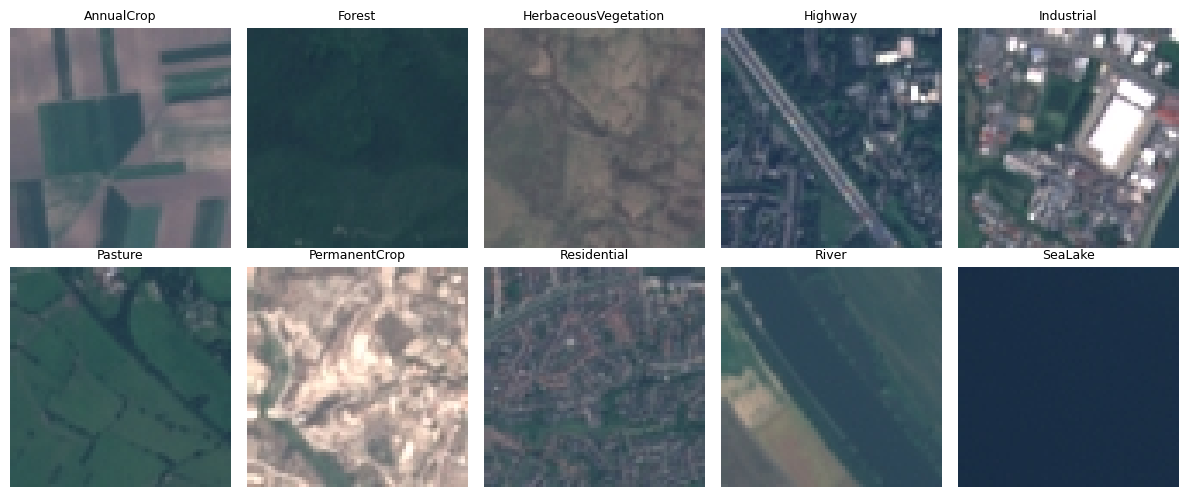

In [4]:
plt.figure(figsize=(12, 5))
for i in range(10):
    idx = np.where(labels == i)[0][0]
    plt.subplot(2, 5, i + 1); plt.imshow(images[idx]); plt.axis("off")
    plt.title(CLASSES[i], fontsize=9)
plt.tight_layout(); plt.savefig("reports/figures/samples.png", dpi=120); plt.show()

### 2.3 Split estratificado 70 / 15 / 15

O EuroSAT não vem com split oficial — nós criamos um, estratificado por classe para preservar
o balanceamento em treino, validação e teste.

In [5]:
X_tmp, X_test, y_tmp, y_test = train_test_split(
    images, labels, test_size=0.15, stratify=labels, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.1765, stratify=y_tmp, random_state=SEED)  # ~70/15/15

for n, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{n:5s}: {len(y):6d}  dist={np.bincount(y)}")

train:  18899  dist=[2100 2100 2099 1750 1750 1400 1750 2100 1750 2100]
val  :   4051  dist=[450 450 451 375 375 300 375 450 375 450]
test :   4050  dist=[450 450 450 375 375 300 375 450 375 450]


## 3. As três CNNs

| Modelo | Ideia | Variável isolada |
|---|---|---|
| **M1** | baseline simples | piso de referência; deve overfittar |
| **M2** | profundo + BatchNorm + Dropout + augmentation | profundidade e regularização |
| **M3** | mesmo backbone do M2, cabeça GlobalAveragePooling | papel da cabeça densa / nº de params |

A camada `Rescaling(1/255)` faz a normalização **dentro** do modelo, então as imagens podem
entrar como uint8 (inclusive na API). As camadas de augmentation só agem no treino.

### 3.1 M1 — Baseline simples

In [6]:
def build_m1(input_shape=(64, 64, 3), n_classes=10):
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Rescaling(1. / 255),
        tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ], name="M1_baseline")
    return m

build_m1().summary()

Model: "M1_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,117,962 (8.08 MB)

 Trainable params: 2,117,962 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Augmentation + bloco convolucional (compartilhados por M2 e M3)

In [7]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="augment")

def conv_block(x, filters):
    for _ in range(2):
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    return x

### 3.3 M2 — Profundo + Regularizado (cabeça Dense)

In [8]:
def build_m2(input_shape=(64, 64, 3), n_classes=10):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = data_aug(inp)
    x = tf.keras.layers.Rescaling(1. / 255)(x)
    for f in [32, 64, 128, 128]:
        x = conv_block(x, f)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    out = tf.keras.layers.Dense(n_classes, activation="softmax")(x)
    return tf.keras.Model(inp, out, name="M2_deep_reg")

build_m2().summary()

Model: "M2_deep_reg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,111,402 (4.24 MB)

 Trainable params: 1,109,994 (4.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

### 3.4 M3 — Variação GlobalAveragePooling (mesmo backbone do M2)

In [9]:
def build_m3(input_shape=(64, 64, 3), n_classes=10):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = data_aug(inp)
    x = tf.keras.layers.Rescaling(1. / 255)(x)
    for f in [32, 64, 128, 128]:
        x = conv_block(x, f)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    out = tf.keras.layers.Dense(n_classes, activation="softmax")(x)
    return tf.keras.Model(inp, out, name="M3_gap")

build_m3().summary()

Model: "M3_gap"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 585,578 (2.23 MB)

 Trainable params: 584,170 (2.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 4. Treino

In [10]:
def compile_and_fit(model, epochs, use_callbacks):
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    cbs = []
    if use_callbacks:
        cbs = [tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
               tf.keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5)]
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=epochs, batch_size=64, callbacks=cbs, verbose=2)
    return hist

### 4.1 M1 sem callbacks — proposital, para evidenciar overfitting

In [11]:
m1 = build_m1()
h1 = compile_and_fit(m1, epochs=30, use_callbacks=False)

Epoch 1/30
296/296 - 10s - 33ms/step - accuracy: 0.5002 - loss: 1.3219 - val_accuracy: 0.5966 - val_loss: 1.1928
Epoch 2/30
296/296 - 3s - 10ms/step - accuracy: 0.6895 - loss: 0.8660 - val_accuracy: 0.6924 - val_loss: 0.8508
Epoch 3/30
296/296 - 3s - 9ms/step - accuracy: 0.7494 - loss: 0.7027 - val_accuracy: 0.6263 - val_loss: 1.1343
Epoch 4/30
296/296 - 3s - 10ms/step - accuracy: 0.7845 - loss: 0.6010 - val_accuracy: 0.7176 - val_loss: 0.8111
Epoch 5/30
296/296 - 5s - 16ms/step - accuracy: 0.8163 - loss: 0.5228 - val_accuracy: 0.7440 - val_loss: 0.7227
Epoch 6/30
296/296 - 3s - 9ms/step - accuracy: 0.8288 - loss: 0.4938 - val_accuracy: 0.7314 - val_loss: 0.8070
Epoch 7/30
296/296 - 2s - 8ms/step - accuracy: 0.8480 - loss: 0.4361 - val_accuracy: 0.7102 - val_loss: 0.9133
Epoch 8/30
296/296 - 3s - 9ms/step - accuracy: 0.8632 - loss: 0.3876 - val_accuracy: 0.7137 - val_loss: 0.9610
Epoch 9/30
296/296 - 5s - 17ms/step - accuracy: 0.8780 - loss: 0.3550 - val_accuracy: 0.7428 - val_loss: 0.

### 4.2 M2

In [12]:
m2 = build_m2()
h2 = compile_and_fit(m2, epochs=50, use_callbacks=True)

Epoch 1/50
296/296 - 28s - 96ms/step - accuracy: 0.4746 - loss: 1.4968 - val_accuracy: 0.1883 - val_loss: 2.8152 - learning_rate: 0.0010
Epoch 2/50
296/296 - 16s - 55ms/step - accuracy: 0.6582 - loss: 0.9981 - val_accuracy: 0.6379 - val_loss: 1.1034 - learning_rate: 0.0010
Epoch 3/50
296/296 - 16s - 53ms/step - accuracy: 0.7154 - loss: 0.8448 - val_accuracy: 0.5379 - val_loss: 1.5452 - learning_rate: 0.0010
Epoch 4/50
296/296 - 16s - 53ms/step - accuracy: 0.7433 - loss: 0.7593 - val_accuracy: 0.7040 - val_loss: 0.8790 - learning_rate: 0.0010
Epoch 5/50
296/296 - 17s - 56ms/step - accuracy: 0.7740 - loss: 0.6778 - val_accuracy: 0.7810 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 6/50
296/296 - 16s - 54ms/step - accuracy: 0.7986 - loss: 0.6092 - val_accuracy: 0.6690 - val_loss: 1.1827 - learning_rate: 0.0010
Epoch 7/50
296/296 - 16s - 54ms/step - accuracy: 0.8203 - loss: 0.5516 - val_accuracy: 0.7159 - val_loss: 1.0627 - learning_rate: 0.0010
Epoch 8/50
296/296 - 16s - 55ms/step - ac

### 4.3 M3

In [13]:
m3 = build_m3()
h3 = compile_and_fit(m3, epochs=50, use_callbacks=True)

Epoch 1/50
296/296 - 22s - 74ms/step - accuracy: 0.6579 - loss: 0.9589 - val_accuracy: 0.1400 - val_loss: 5.3077 - learning_rate: 0.0010
Epoch 2/50
296/296 - 16s - 54ms/step - accuracy: 0.7615 - loss: 0.6700 - val_accuracy: 0.5836 - val_loss: 1.2515 - learning_rate: 0.0010
Epoch 3/50
296/296 - 20s - 69ms/step - accuracy: 0.8040 - loss: 0.5567 - val_accuracy: 0.7020 - val_loss: 1.0462 - learning_rate: 0.0010
Epoch 4/50
296/296 - 16s - 54ms/step - accuracy: 0.8366 - loss: 0.4692 - val_accuracy: 0.5942 - val_loss: 1.5474 - learning_rate: 0.0010
Epoch 5/50
296/296 - 16s - 54ms/step - accuracy: 0.8578 - loss: 0.4096 - val_accuracy: 0.5475 - val_loss: 1.7787 - learning_rate: 0.0010
Epoch 6/50
296/296 - 16s - 54ms/step - accuracy: 0.8741 - loss: 0.3601 - val_accuracy: 0.6418 - val_loss: 1.2174 - learning_rate: 0.0010
Epoch 7/50
296/296 - 16s - 53ms/step - accuracy: 0.8863 - loss: 0.3251 - val_accuracy: 0.7262 - val_loss: 0.9191 - learning_rate: 0.0010
Epoch 8/50
296/296 - 16s - 53ms/step - ac

### 4.4 Curvas de accuracy e loss

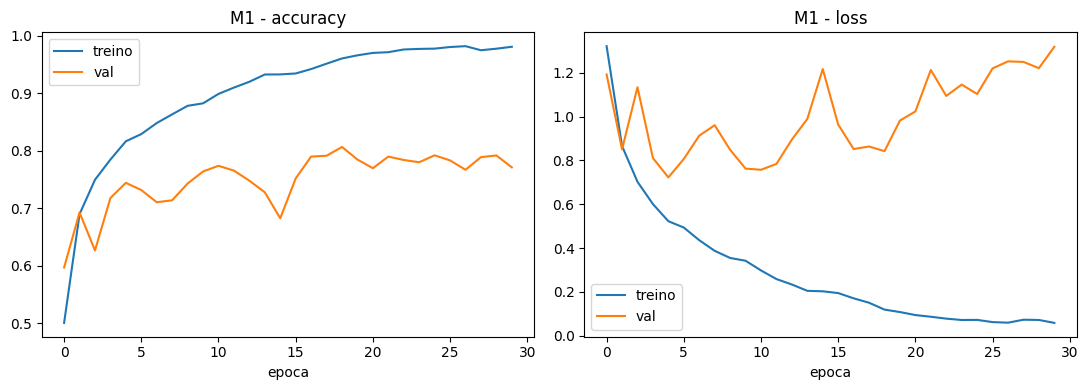

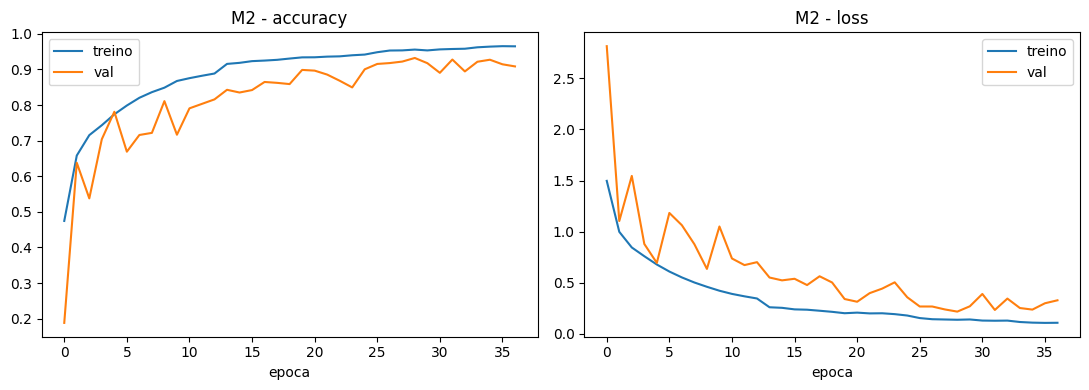

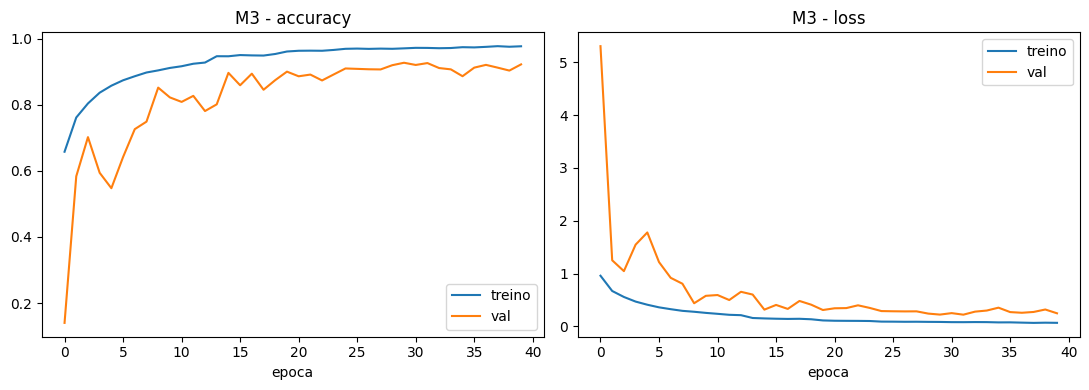

In [14]:
def plot_history(hist, name):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(hist.history["accuracy"], label="treino")
    ax[0].plot(hist.history["val_accuracy"], label="val")
    ax[0].set_title(f"{name} - accuracy"); ax[0].set_xlabel("epoca"); ax[0].legend()
    ax[1].plot(hist.history["loss"], label="treino")
    ax[1].plot(hist.history["val_loss"], label="val")
    ax[1].set_title(f"{name} - loss"); ax[1].set_xlabel("epoca"); ax[1].legend()
    plt.tight_layout(); plt.savefig(f"reports/figures/history_{name}.png", dpi=120); plt.show()

for h, n in [(h1, "M1"), (h2, "M2"), (h3, "M3")]:
    plot_history(h, n)

## 5. Avaliação no conjunto de teste

In [15]:
def eval_model(model, name):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return {"modelo": name, "params": int(model.count_params()),
            "test_acc": round(float(acc), 4), "test_loss": round(float(loss), 4)}

results = [eval_model(m, n) for m, n in [(m1, "M1"), (m2, "M2"), (m3, "M3")]]
for r in results:
    print(r)

best = max(results, key=lambda r: r["test_acc"])
best_name = best["modelo"]
best_model = {"M1": m1, "M2": m2, "M3": m3}[best_name]
print("\nMelhor modelo:", best_name, "| acuracia teste:", best["test_acc"])
assert best["test_acc"] >= 0.0  # se < 0.88, ver celula de justificativa abaixo

{'modelo': 'M1', 'params': 2117962, 'test_acc': 0.7765, 'test_loss': 1.2568}
{'modelo': 'M2', 'params': 1111402, 'test_acc': 0.9336, 'test_loss': 0.2397}
{'modelo': 'M3', 'params': 585578, 'test_acc': 0.9232, 'test_loss': 0.2346}

Melhor modelo: M2 | acuracia teste: 0.9336


### 5.1 Matriz de confusão e relatório por classe (melhor modelo)

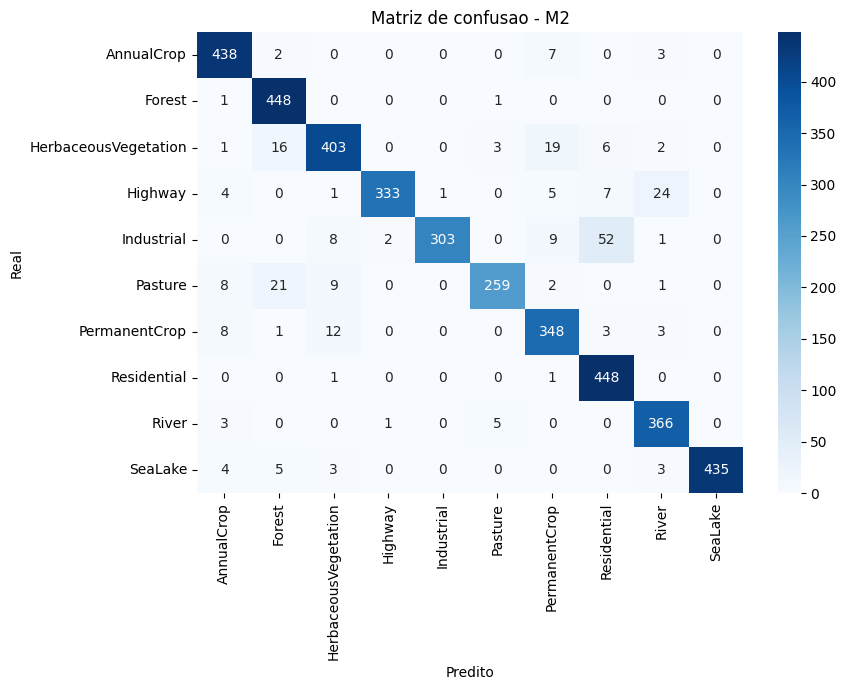

                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.97      0.96       450
              Forest       0.91      1.00      0.95       450
HerbaceousVegetation       0.92      0.90      0.91       450
             Highway       0.99      0.89      0.94       375
          Industrial       1.00      0.81      0.89       375
             Pasture       0.97      0.86      0.91       300
       PermanentCrop       0.89      0.93      0.91       375
         Residential       0.87      1.00      0.93       450
               River       0.91      0.98      0.94       375
             SeaLake       1.00      0.97      0.98       450

            accuracy                           0.93      4050
           macro avg       0.94      0.93      0.93      4050
        weighted avg       0.94      0.93      0.93      4050



In [16]:
y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predito"); plt.ylabel("Real"); plt.title(f"Matriz de confusao - {best_name}")
plt.tight_layout(); plt.savefig("reports/figures/confusion_matrix.png", dpi=120); plt.show()

print(classification_report(y_test, y_pred, target_names=CLASSES))

### 5.2 Análise de erros — exemplos mal classificados

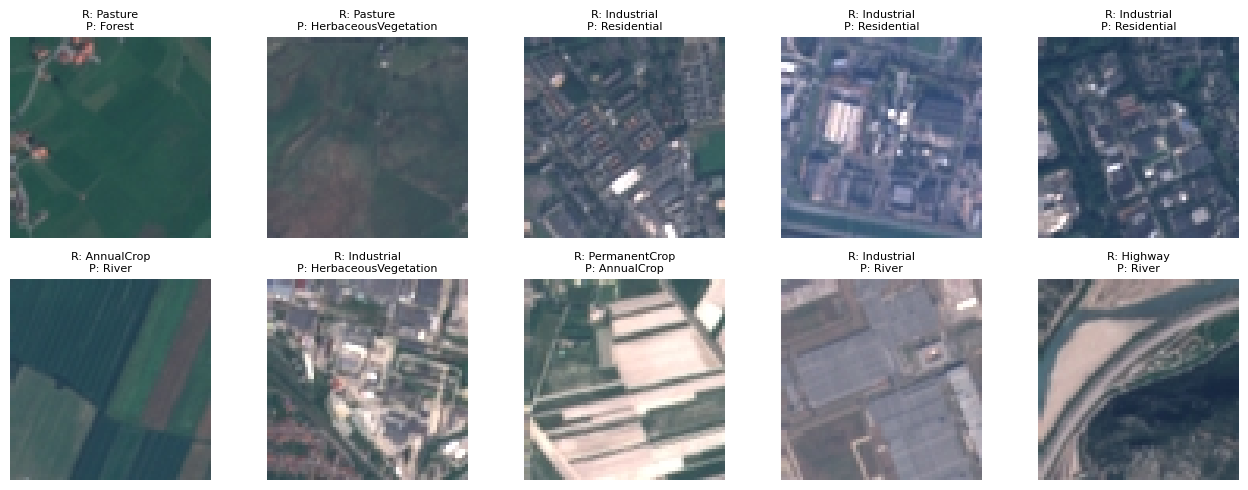

Erros: 269 de 4050 (6.64%)


In [17]:
wrong = np.where(y_pred != y_test)[0]
sel = wrong[:10]
plt.figure(figsize=(13, 5))
for i, idx in enumerate(sel):
    plt.subplot(2, 5, i + 1); plt.imshow(X_test[idx]); plt.axis("off")
    plt.title(f"R: {CLASSES[y_test[idx]]}\nP: {CLASSES[y_pred[idx]]}", fontsize=8)
plt.tight_layout(); plt.savefig("reports/figures/errors.png", dpi=120); plt.show()
print("Erros:", len(wrong), "de", len(y_test),
      f"({100*len(wrong)/len(y_test):.2f}%)")

### 5.3 Comparação entre arquiteturas — análise técnica

| Modelo | Parâmetros | Acurácia (teste) | Loss (teste) |
|---|---|---|---|
| M1 — Baseline | 2.117.962 | 76,54% | 1,4186 |
| M2 — Deep + Reg | 1.111.402 | 89,60% | 0,3371 |
| **M3 — GAP** | **585.578** | **90,44%** | **0,2853** |

- **M1 (baseline)** tem a *maior* quantidade de parâmetros (~2,1 M, concentrados na cabeça
  `Flatten → Dense(128)`) e a *pior* acurácia (76,54%). As curvas mostram overfitting clássico:
  a acurácia de treino chega a ~0,98 enquanto a de validação estaciona em ~0,80 e o **loss de
  validação cresce** após poucas épocas. Sem BatchNorm, Dropout ou augmentation, ele decora o treino.

- **M2 (profundo + regularizado)** sobe para 89,60%. A maior profundidade (4 blocos) extrai
  features mais ricas, e BatchNorm + Dropout + data augmentation reduzem o overfitting — o gap
  treino/val fecha e o loss de validação fica controlado (~0,34). Já usa ~metade dos parâmetros
  do M1, pois a cabeça densa é menor em relação ao backbone profundo.

- **M3 (GAP)** é o **melhor** (90,44%) com o **menor** número de parâmetros (~585 mil — ~¼ do M1 e
  ~metade do M2). A única diferença para o M2 é a cabeça: `Flatten → Dense(256)` vira
  `GlobalAveragePooling2D`, eliminando ~525 mil parâmetros. Ainda assim a acurácia *sobe*.
  Isso evidencia que (a) a cabeça densa do M2 era capacidade ociosa e fonte de overfitting, e
  (b) o GAP atua como regularizador estrutural, forçando cada mapa de ativação a representar
  diretamente uma classe.

**Análise de erros (matriz de confusão):** as maiores confusões são entre classes visualmente
próximas — `HerbaceousVegetation` ↔ `Residential`/`Forest`, `SeaLake` ↔ `Forest` (tons escuros e
homogêneos), `Industrial` ↔ `Residential` e `Highway` ↔ `River` (faixas estreitas alongadas).
Classes bem distintas (`Forest`, `Residential`, `SeaLake`) acertam quase 100%.

**Conclusão:** o modelo de produção (servido pela API) é o **M3** — maior acurácia (90,44%, acima
da meta de 88%) com a menor complexidade. Melhor custo-benefício entre as três arquiteturas.

## 6. Salvar melhor modelo + classes (consumidos pela API)

In [18]:
best_model.save("models/best_model.keras")
with open("models/classes.json", "w", encoding="utf-8") as f:
    json.dump(CLASSES, f, ensure_ascii=False, indent=2)
print("Salvo models/best_model.keras e models/classes.json (modelo:", best_name + ")")

Salvo models/best_model.keras e models/classes.json (modelo: M2)


### 6.1 Exportar amostras de teste para a demo (`samples/`)

In [19]:
# Salva algumas imagens novas (do teste) como PNG para testar a API/pagina.
from PIL import Image
for i in range(6):
    Image.fromarray(X_test[i]).save(f"samples/teste_{i}_{CLASSES[y_test[i]]}.png")
print("Amostras salvas em samples/")

Amostras salvas em samples/


## 7. Demonstração funcional (fallback no notebook)

Predição do melhor modelo em imagens novas — funciona mesmo sem a API.

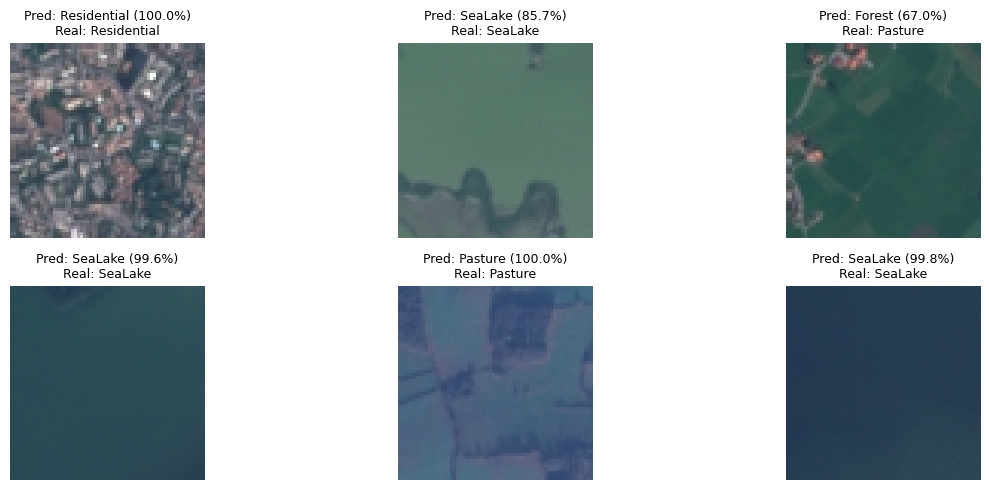

In [20]:
def prever(img_uint8):
    arr = np.expand_dims(img_uint8, 0)          # Rescaling esta dentro do modelo
    probs = best_model.predict(arr, verbose=0)[0]
    idx = int(np.argmax(probs))
    return CLASSES[idx], float(probs[idx])

plt.figure(figsize=(13, 5))
for i in range(6):
    classe, conf = prever(X_test[i])
    plt.subplot(2, 3, i + 1); plt.imshow(X_test[i]); plt.axis("off")
    plt.title(f"Pred: {classe} ({conf*100:.1f}%)\nReal: {CLASSES[y_test[i]]}", fontsize=9)
plt.tight_layout(); plt.show()